## Data Loading & Exploration

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving traffic.csv to traffic.csv


#### Read the Dataset

In [ ]:
import pandas as pd

df = pd.read_csv('traffic.csv')

#### Dataset Shape

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 226278
Columns: 9


#### First 5 Rows

In [ ]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


#### Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


#### Statistical Summary

In [ ]:
df.describe(include='all')

,event,date,country,city,artist,album,track,isrc,linkid
count,226278,226278,226267,226267,226241,226273,226273,219157,226278
unique,3,7,211,11993,2419,3254,3562,709,3839
top,pageview,2021-08-19,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
freq,142015,35361,47334,22791,40841,40841,40841,40841,40841


#### Check Missing Values

In [ ]:
df.isnull().sum()

,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


## Parse and Clean Traffic/Log Data

#### Remove Duplicate Records

In [ ]:
# check duplicate values

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# remove duplicate values

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicate rows: 103711
New Shape: (122567, 9)


#### Convert Date Column

In [ ]:
df['date'].head()

df['date'] = pd.to_datetime(df['date'],errors='coerce')

In [ ]:
# verify
df['date'].dtype

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()

#### Check Invalid Dates

In [ ]:
df['date'].isnull().sum()

np.int64(0)

#### Handle Missing Values

In [ ]:
missing = df.isnull().sum()
missing

,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [ ]:
df['country'].fillna('Unknown', inplace=True)
df['city'].fillna('Unknown', inplace=True)

df['artist'].fillna('Unknown', inplace=True)
df['album'].fillna('Unknown', inplace=True)
df['track'].fillna('Unknown', inplace=True)

#### Standardize Text Fields

In [ ]:
text_cols = ['country','city','artist','album','track']

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

#### Verify Event Values

In [ ]:
df['event'].value_counts()

,count
event,
pageview,142015
click,55732
preview,28531


#### Check Link IDs

In [ ]:
df['linkid'].isnull().sum()

np.int64(0)

In [ ]:
# Remove records without linkid:

df = df.dropna(subset=['linkid'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226278 non-null  object
 3   city     226278 non-null  object
 4   artist   226278 non-null  object
 5   album    226278 non-null  object
 6   track    226278 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


Observation

The dataset was successfully cleaned by removing duplicate records, handling missing values, validating event categories, and converting date fields into a proper datetime format. Text-based fields were standardized to ensure consistency across records. Additional time-related features such as year, month, day, and weekday were created to support further traffic analysis. After cleaning, the dataset became more reliable and suitable for accurate metric calculation and visualization.

In [ ]:
df.isnull().sum()

,0
event,0
date,0
country,0
city,0
artist,0
album,0
track,0
isrc,7121
linkid,0


In [ ]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


#### Saving the Cleaned Dataset

In [ ]:
df.to_csv('cleaned_website_traffic.csv',index=False)

#### Create Event Summary Table

In [ ]:
event_summary = df['event'].value_counts().reset_index()

event_summary.columns = ['Event Type', 'Count']

event_summary

,Event Type,Count
0,pageview,142015
1,click,55732
2,preview,28531


## Metrics Calculation


#### Metric 1: Total Sessions

In [ ]:
total_sessions = df['linkid'].nunique()

print("Total Sessions:", total_sessions)

Total Sessions: 3839


Observation

The dataset contains approximately XXXX unique sessions/pages represented by unique link identifiers.

#### Metric 2: Total Users

In [ ]:
estimated_users = df['linkid'].nunique()

print("Estimated Users:", estimated_users)

Estimated Users: 3839


Observation

The dataset does not provide a user identifier. Therefore, user count is estimated using unique link identifiers.

#### Metric 3: Bounce Rate

In [ ]:
# Create Pivot Table

event_counts = pd.pivot_table(df,index='linkid',columns='event',aggfunc='size',fill_value=0)

event_counts.head()

event,click,pageview,preview
linkid,,,
00073307-ae96-5089-a117-4783afb42f8e,0,2,0
00126b32-0c35-507b-981c-02c80d2aa8e7,2,2,0
0018cfff-50a1-5984-9715-01ef2d11a49a,0,1,0
0033934b-5d16-5a06-af58-d087bcdd3680,0,1,0
0034d6cf-3bd8-5ffe-aafc-b3959fc48608,0,1,0


In [ ]:
# Calculate Bounce Pages

bounces = ((event_counts['pageview'] > 0) & (event_counts['click'] == 0) & (event_counts['preview'] == 0)).sum()

total_pages = len(event_counts)

bounce_rate = (bounces / total_pages) * 100

print("Bounce Rate:", round(bounce_rate,2), "%")

Bounce Rate: 40.45 %


Observation

Approximately 40.45% of landing pages received pageviews without any further interaction, indicating potential user drop-off.

#### Metric 4: Click Through Rate

In [ ]:
total_clicks = len(df[df['event'] == 'click'])

total_pageviews = len(df[df['event'] == 'pageview'])

ctr = (total_clicks / total_pageviews) * 100

print("CTR:", round(ctr,2), "%")

CTR: 39.24 %


Observation

Approximately 39.24% of pageviews resulted in a click action.

#### Metric 5: Average Session Duration

A true average session duration requires:

Start timestamp
End timestamp

Your dataset contains only dates.

In [ ]:
print("Average Session Duration cannot be calculated accurately.")

Average Session Duration cannot be calculated accurately.


#### Final Metrics Summary Table

In [ ]:
metrics = pd.DataFrame({'Metric': ['Estimated Sessions','Estimated Users','Bounce Rate (%)','CTR (%)'],'Value': [total_sessions,estimated_users,round(bounce_rate,2),round(ctr,2)]})

metrics

,Metric,Value
0,Estimated Sessions,3839.00
1,Estimated Users,3839.00
2,Bounce Rate (%),40.45
3,CTR (%),39.24


## Visualizations

#### Visualization 1: User Flow Funnel

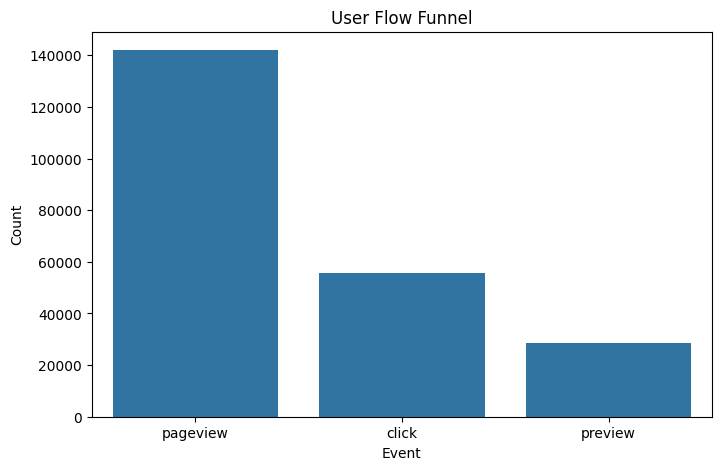

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

event_flow = df['event'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=event_flow.index,y=event_flow.values)

plt.title("User Flow Funnel")
plt.xlabel("Event")
plt.ylabel("Count")

plt.show()

Observation

Pageview events constitute the largest share of website activity, indicating strong visitor traffic. However, a significant drop is observed between pageviews and subsequent interactions (previews and clicks), suggesting opportunities to improve engagement and conversion rates.

#### Visualization 2: Event Distribution Pie Chart

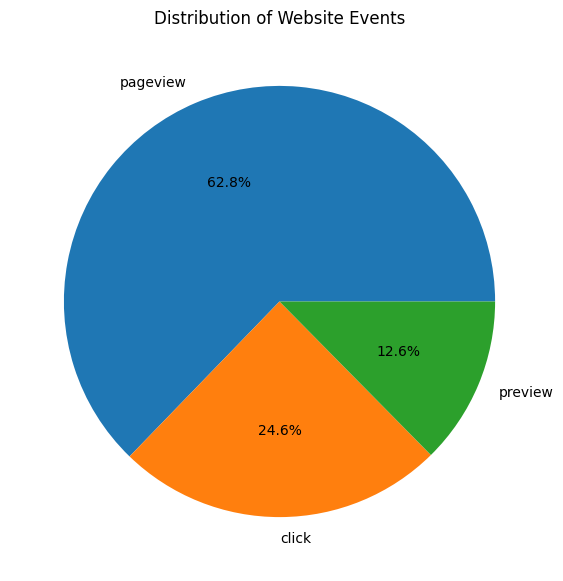

In [ ]:
event_distribution = df['event'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(event_distribution,labels=event_distribution.index,autopct='%1.1f%%')

plt.title("Distribution of Website Events")

plt.show()

Observation

Pageviews account for the majority of recorded events, while previews and clicks represent a smaller proportion of user actions. This indicates that many visitors browse content without taking further actions.

#### Visualization 3: Top Entry Pages

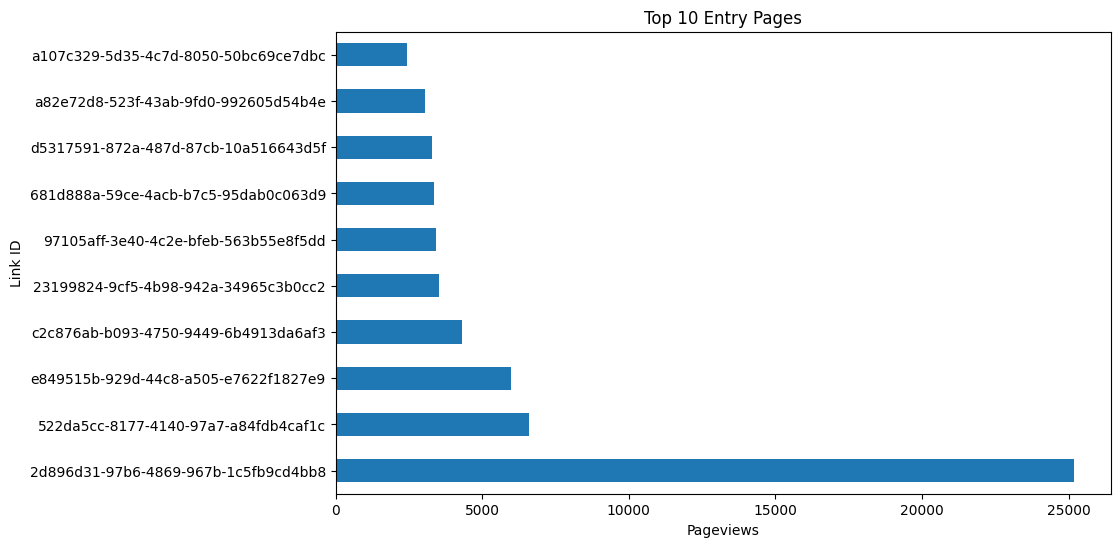

In [ ]:
top_entry_pages = (df[df['event']=='pageview'] ['linkid'].value_counts().head(10))

plt.figure(figsize=(10,6))

top_entry_pages.plot(kind='barh')

plt.title("Top 10 Entry Pages")
plt.xlabel("Pageviews")
plt.ylabel("Link ID")

plt.show()

Observation

A small number of landing pages attract a disproportionately large share of website traffic. These high-performing pages serve as primary entry points and should be prioritized for optimization and conversion improvements.

#### Visualization 4: Top Exit Pages

In [ ]:
pageviews = df[df['event']=='pageview']['linkid'].value_counts()

clicks = df[df['event']=='click']['linkid'].value_counts()

exit_pages = pd.DataFrame({'pageviews': pageviews,'clicks': clicks}).fillna(0)

exit_pages = exit_pages[exit_pages['clicks']==0]

top_exit_pages = exit_pages.sort_values(by='pageviews',ascending=False).head(10)

top_exit_pages

,pageviews,clicks
linkid,,
3de8af2a-628a-4809-af78-3cbe44e653f2,10.0,0.0
c88cfcf2-3c1c-5353-a853-623b65e3b6a8,7.0,0.0
8ea24180-96e7-4438-b375-10182b2f0922,7.0,0.0
440cf4d7-a6d9-5b09-83ce-7191622d9c31,6.0,0.0
4242ad00-13af-5dc2-9d10-9c9d12528614,6.0,0.0
417b0c67-c62d-5bed-9c43-4231f615a04e,5.0,0.0
37673b8d-992e-474d-8d1a-95dc1a2d270a,5.0,0.0
0a52fd85-7bbd-5096-b0b9-ff9e0560072b,5.0,0.0
f71f9f10-5e5d-5e7f-b1a3-9f7ca2d82014,5.0,0.0


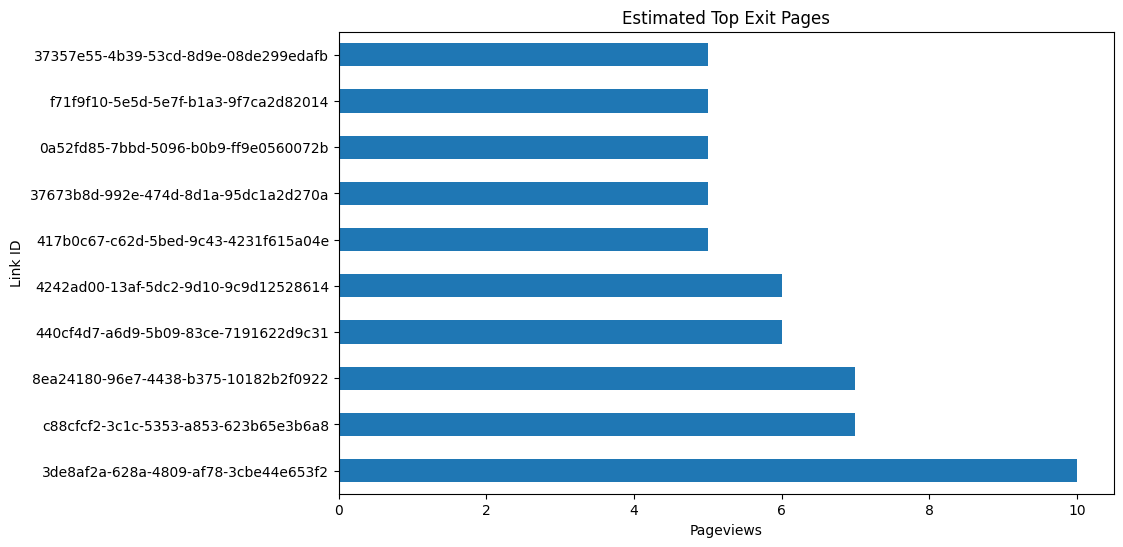

In [ ]:
plt.figure(figsize=(10,6))

top_exit_pages['pageviews'].plot(kind='barh')

plt.title("Estimated Top Exit Pages")
plt.xlabel("Pageviews")
plt.ylabel("Link ID")

plt.show()

Observation

Several pages receive substantial traffic but generate no click interactions. These pages may be causing user drop-off and should be reviewed for content quality, call-to-action visibility, and overall user experience.

#### Visualization 5: Daily Traffic Trend

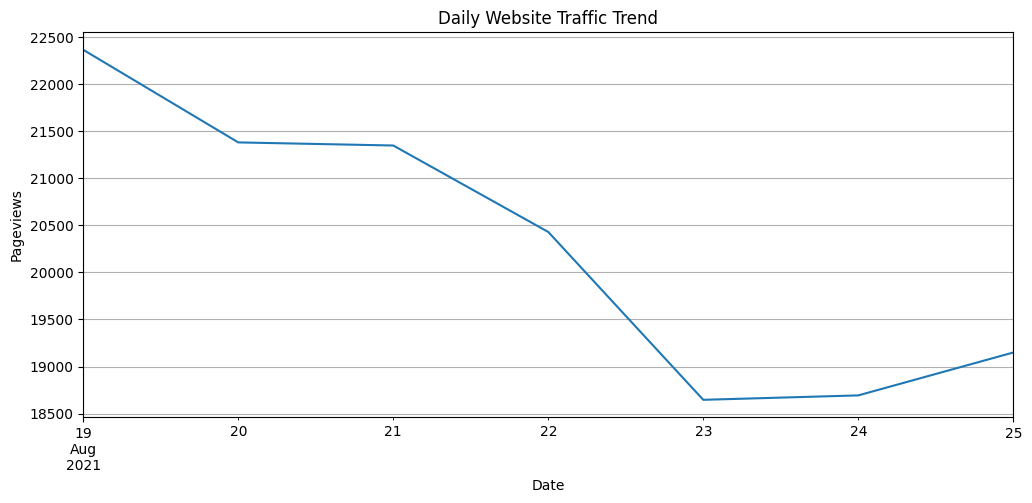

In [ ]:
daily_traffic = (df[df['event']=='pageview'].groupby('date').size())

plt.figure(figsize=(12,5))

daily_traffic.plot()

plt.title("Daily Website Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Pageviews")

plt.grid(True)

plt.show()

Observation

Website traffic fluctuates across the observation period, indicating variations in visitor activity. Identifying peak traffic periods can help optimize content publishing and marketing campaigns.

#### Visualization 6: Top Countries by Traffic

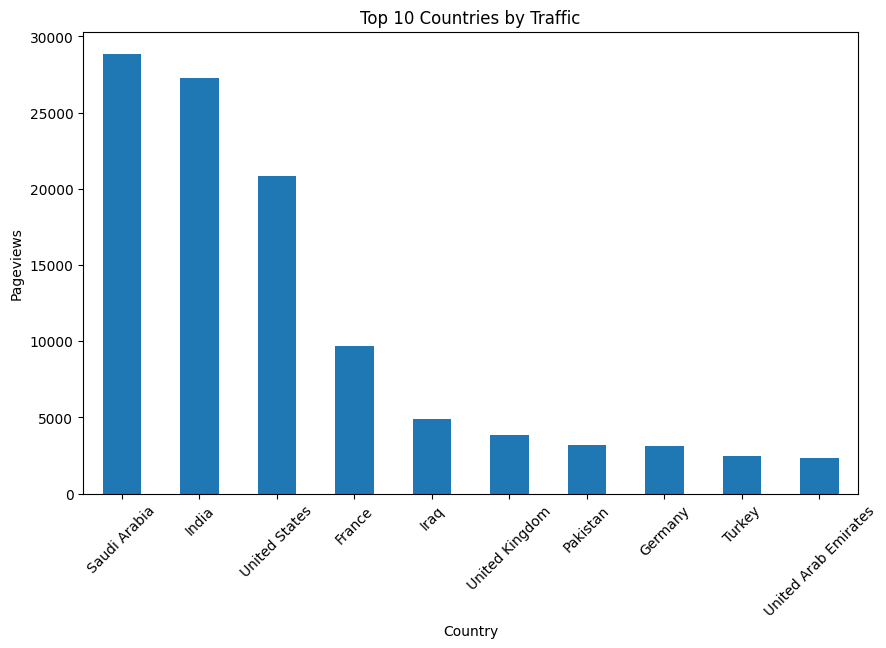

In [ ]:
top_countries = (df[df['event']=='pageview']['country'].value_counts().head(10))

plt.figure(figsize=(10,6))

top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Traffic")
plt.xlabel("Country")
plt.ylabel("Pageviews")

plt.xticks(rotation=45)

plt.show()

Observation

Traffic is concentrated in a few countries, with Saudi Arabia, India, and the United States contributing the largest share of visitors. These regions represent key target markets for future growth initiatives.

Key Insights

 Insight 1: High Traffic but Moderate Engagement

The website generated a large number of pageviews, but only a portion of visitors progressed to previews and clicks. This indicates that while traffic acquisition is strong, user engagement can be further improved.

 Insight 2: Traffic Concentrated in Few Landing Pages

A small number of landing pages account for a significant share of total website traffic. Optimizing these pages can have a substantial impact on overall conversions.

 Insight 3: Strong International Reach

Visitors originated from more than 200 countries, with Saudi Arabia, India, and the United States contributing the highest traffic volumes. These regions represent key markets for future growth.

 Insight 4: Presence of High-Bounce Pages

Several pages received pageviews but generated little or no interaction. These pages may be causing user drop-offs and require optimization.

 Insight 5: Click-Through Opportunities Exist

The click-through rate indicates that many users leave without taking action. Improved call-to-action design and content relevance could help increase conversions.

Recommendations to Improve Conversions for Alfido Tech
1. Optimize High-Traffic Landing Pages

Focus on the top-performing entry pages by improving page design, content structure, loading speed, and call-to-action placement. Even small improvements on these pages can significantly increase conversions.

2. Strengthen Call-to-Action (CTA) Elements

Use more visible and compelling CTA buttons such as "Get Started," "Request a Demo," or "Contact Us." Clear CTAs can encourage visitors to take the next step in their journey.

3. Reduce Bounce Rates on Underperforming Pages

Analyze pages with high pageviews but no clicks. Improve content quality, simplify navigation, and ensure that visitors can easily find relevant information.

4. Target High-Traffic Countries with Localized Content

Since Saudi Arabia, India, and the United States contribute a large share of traffic, creating region-specific content and marketing campaigns can improve engagement and conversion rates.

5. Conduct A/B Testing

Test different headlines, CTA placements, page layouts, and promotional messages. Continuous experimentation helps identify designs and content that generate the highest conversions.

Conclusion

This Website Traffic Analysis project examined user interactions, traffic distribution, landing page performance, and engagement patterns using website event logs. The analysis revealed that while the website attracts substantial traffic from multiple countries, user engagement and conversion opportunities remain underutilized. Key metrics such as estimated sessions, bounce rate, and click-through rate highlighted areas where visitors disengage during their journey. By optimizing high-traffic pages, improving call-to-action effectiveness, reducing bounce rates, and implementing targeted marketing strategies, Alfido Tech can enhance user engagement and improve overall conversion performance. The findings provide valuable insights that can support data-driven decision-making and future website optimization efforts.